In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import altair as alt
import scipy.stats as stats

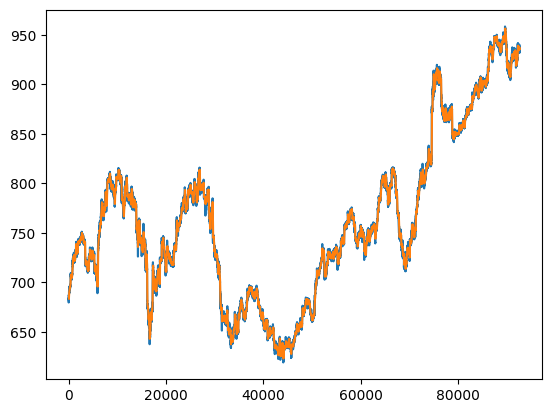

In [19]:
Axisbank=pd.read_csv("data/AXISBANK_minute.csv")
Axisbank.columns=Axisbank.columns.str.strip()
Day=Axisbank
Avg=Day['close'].rolling(window=60).mean()
plt.plot(np.linspace(0,len(Day),len(Day)),Day['close'])
plt.plot(np.linspace(0,len(Avg),len(Avg)),Avg)
plt.show()
Adani=pd.read_csv("data/ADANIENT_minute.csv")
Adani2=pd.read_csv("data/ADANIENT_minute_2.csv")
Adani2.columns=Adani2.columns.str.strip()
Axisbank2=pd.read_csv("data/AXISBANK_minute2.csv")
Axisbank2.columns=Axisbank2.columns.str.strip()
Bajaj2=pd.read_csv("data/BAJAJ-AUTO_minute_2.csv")
Bajaj2.columns=Bajaj2.columns.str.strip()

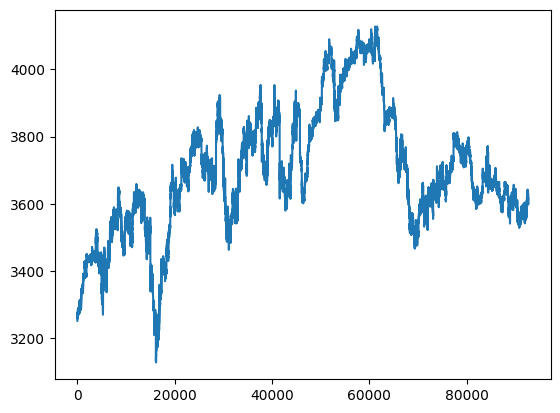

In [20]:
Bajaj=pd.read_csv("data/BAJAJ-AUTO_minute.csv")
plt.plot(np.linspace(0,len(Bajaj),len(Bajaj)),Bajaj['close'])
plt.show()

In [4]:
cost_per_side=0
def strat(data,e,Ts,Tl,sigmao,t):
    Data = data.copy().reset_index(drop=True)
    n = len(Data)
    
    # 2. Compute log returns and price differences
    LogReturns = np.log(Data['close'] / Data['close'].shift(1))
    Difs = Data['close'] - Data['close'].shift(1)
    # 3. Calculate global volatility metric (matching your original setup)
    sigma = Difs.dropna().expanding().std()
    rho = (sigma / sigmao) ** 2
    
    # 4. Rolling indicators shifted by 1 to strictly prevent look-ahead bias
    Small = Difs.rolling(window=Ts).mean().shift(1)
    Long = Difs.rolling(window=Tl).mean().shift(1)
    # 5. Mathematical equations executed simultaneously across vectors
    a = Small / (1 + rho / Ts)
    b = Long / (1 + rho / Tl)
    
    denominator = ((a - b) ** 2) + 1e-9
    T = (-1 * np.log(e) * 2 * sigma * sigma) / denominator
    df=T.dropna()

    ind_true = t * a
    ind_false = T * a + (t - T) * (e * a + (1 - e) * b)
    ind = np.where(T > t, ind_true, ind_false)
    
    
    # Generate the target signal direction (-1, 0, or 1)
    calculated_move = np.where(np.abs(ind) < 1e-2, 0, np.where(ind > 0, 1, -1))
    
    # 6. Periodic Execution Masking: ((x - Tl - 1) % t == 0 and x != Tl + 1)
    indices = np.arange(n)
    trade_mask = ((indices - Tl - 1) % t == 0) & (indices > Tl + 1)
    
    # HOLDING LOGIC: 
    # If it's a decision bar, take the calculated_move. 
    # If not, mark as np.nan so it inherits the previous position during forward-fill.
    moves = np.where(trade_mask, calculated_move, np.nan)
    
    # Convert to a Pandas Series to utilize optimized time-series filling methods
    Moves_Series = pd.Series(moves, index=Data.index)
    
    # ffill() carries the position forward for t bars. 
    # fillna(0) ensures the initialization period (before the first trade) is flat (0).
    Moves_Series = Moves_Series.ffill().fillna(0)
    
    # 7. Compute backtest performance metrics
    loggain = Moves_Series.shift(1) * LogReturns
    loggain.dropna(inplace=True)
    
    # Guard clause against empty arrays or zero volatility
    if len(loggain) == 0 or np.std(loggain) == 0:
        return 0.0
        
    sharperatio = np.sqrt(94500) * (np.mean(loggain) / np.std(loggain))
    marketreturn=np.exp(LogReturns.sum())-1
    stratreturn=np.exp(sum(loggain))-1
    print("Market returns at: "+str(marketreturn))
    print("Strategy return at : "+str(stratreturn))
    print("Sharpe : "+str(sharperatio))

    

In [5]:
cost_per_side=0
def Tseries(data,e,Ts,Tl,sigmao):
    Data = data.copy().reset_index(drop=True)
    
    Difs = Data['close'] - Data['close'].shift(1)
    # 3. Calculate global volatility metric (matching your original setup)
    sigma = Difs.dropna().expanding().std()
    rho = (sigma / sigmao) ** 2
    
    # 4. Rolling indicators shifted by 1 to strictly prevent look-ahead bias
    Small = Difs.rolling(window=Ts).mean().shift(1)
    Long = Difs.rolling(window=Tl).mean().shift(1)
    # 5. Mathematical equations executed simultaneously across vectors
    a = Small / (1 + rho / Ts)
    b = Long / (1 + rho / Tl)
    
    denominator = ((a - b) ** 2) + 1e-9
    T = (-1 * np.log(e) * 2 * sigma * sigma) / denominator
    df=T.dropna()
    return(df)

In [6]:
times=Tseries(Bajaj,0.01,60,1200,0.1)

12.39973154457419


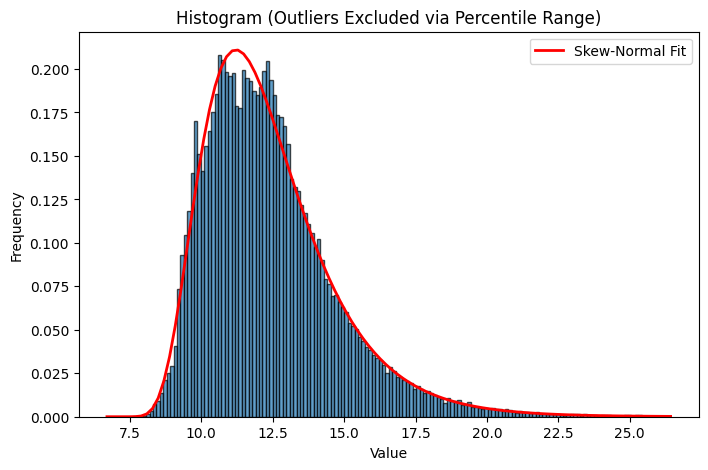

In [7]:
# 3. Plot using the 'range' parameter to truncate the view
data=times
lower_bound = np.percentile(data, 0)
upper_bound = np.percentile(data,100)
plt.figure(figsize=(8, 5))
print(np.log(data).mean())
plt.hist(np.log(data), bins=150, range=(np.log(lower_bound), np.log(upper_bound)), edgecolor='black', alpha=0.7,density=True)
a, b, loc, scale = stats.johnsonsu.fit(np.log(data))

# 3. Plot the theoretical PDF over your log histogram to see the match
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.johnsonsu.pdf(x,a,b,loc,scale)
plt.plot(x, p, 'r-', linewidth=2, label='Skew-Normal Fit')
plt.legend()
plt.title("Histogram (Outliers Excluded via Percentile Range)")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

In [8]:
print(a,b,loc,scale)

-6.857354677059879 2.465429523974594 6.9572293499950995 0.6235157405280289


In [9]:
def Strat(data, e, Ts, Tl, sigmao, t):
    # 1. Create a clean copy and reset index to ensure perfect array alignment
    Data = data.copy().reset_index(drop=True)
    n = len(Data)
    
    # 2. Compute log returns and price differences
    LogReturns = np.log(Data['close'] / Data['close'].shift(1))
    Difs = Data['close'] - Data['close'].shift(1)
    
    # 3. Calculate global volatility metric (matching your original setup)
    sigma = Difs.dropna().expanding().std()
    rho = (sigma / sigmao) ** 2
    
    # 4. Rolling indicators shifted by 1 to strictly prevent look-ahead bias
    Small = Difs.rolling(window=Ts).mean().shift(1)
    Long = Difs.rolling(window=Tl).mean().shift(1)
    
    # 5. Mathematical equations executed simultaneously across vectors
    a = Small / (1 + rho / Ts)
    b = Long / (1 + rho / Tl)
    
    denominator = ((a - b) ** 2) + 1e-9
    T = (-1 * np.log(e) * 2 * sigma * sigma) / denominator
    # Branching paths for 'ind' depending on whether T > t
    ind_true = t * a
    ind_false = T * a + (t - T) * (e * a + (1 - e) * b)
    ind = np.where(T > t, ind_true, ind_false)
    
    # Generate the target signal direction (-1, 0, or 1)
    calculated_move =np.where(abs(ind)<1e-3,0,np.where(ind>0,1,-1))
    
    # 6. Periodic Execution Masking: ((x - Tl - 1) % t == 0 and x != Tl + 1)
    indices = np.arange(n)
    trade_mask = ((indices - Tl - 1) % t == 0) & (indices > Tl + 1)
    
    # HOLDING LOGIC: 
    # If it's a decision bar, take the calculated_move. 
    # If not, mark as np.nan so it inherits the previous position during forward-fill.
    moves = np.where(trade_mask, calculated_move, np.nan)
    
    # Convert to a Pandas Series to utilize optimized time-series filling methods
    Moves_Series = pd.Series(moves, index=Data.index)
    
    # ffill() carries the position forward for t bars. 
    # fillna(0) ensures the initialization period (before the first trade) is flat (0).
    Moves_Series = Moves_Series.ffill().fillna(0)
    
    # 7. Compute backtest performance metrics
    loggain = Moves_Series.shift(1) * LogReturns
    loggain.dropna(inplace=True)
    
    # Guard clause against empty arrays or zero volatility
    if len(loggain) == 0 or np.std(loggain) == 0:
        return 0.0
        
    sharperatio = np.sqrt(94500) * (np.mean(loggain) / np.std(loggain))
    
    return sharperatio

In [10]:
def visualise(data):
    arr=[]
    for x in range(100,10000):
        arr.append(Strat(data,0.01,80,x,0.1,30))
    plt.figure(2)
    plt.hist(arr,density=True,bins=100)
    x=np.linspace(0,len(arr),len(arr))
    plt.figure()
    plt.scatter(x,arr,s=0.5,c=(x+100)%30,cmap="viridis")
    w=100
    plt.axhline(1.8,c="green")
    plt.colorbar()
    plt.show()

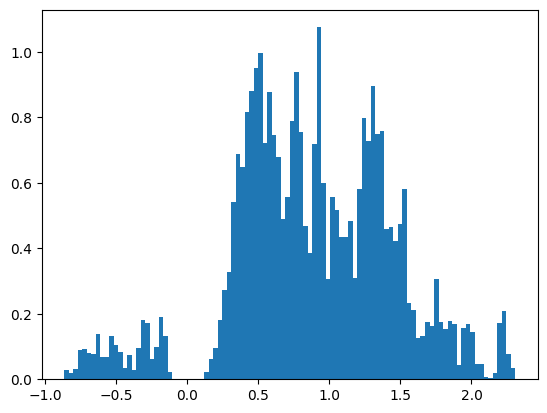

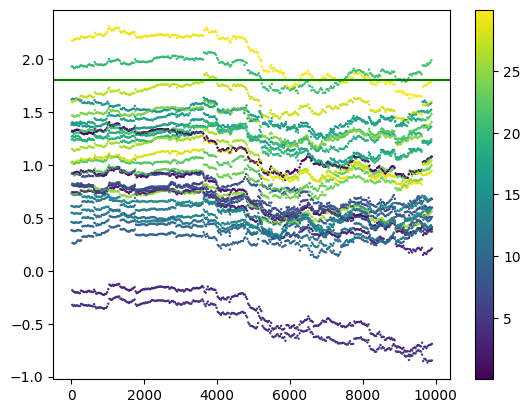

In [11]:
visualise(Bajaj)

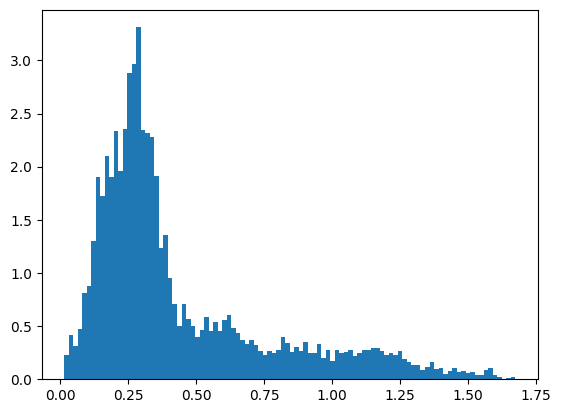

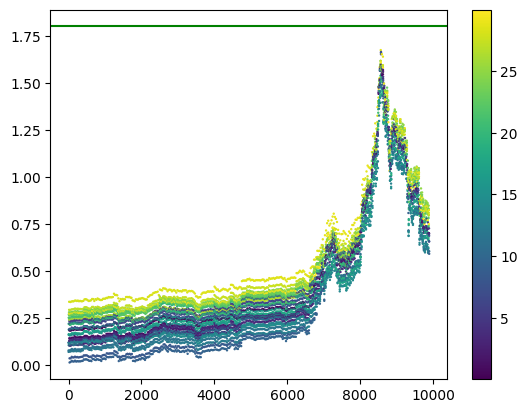

In [14]:
visualise(Adani2)

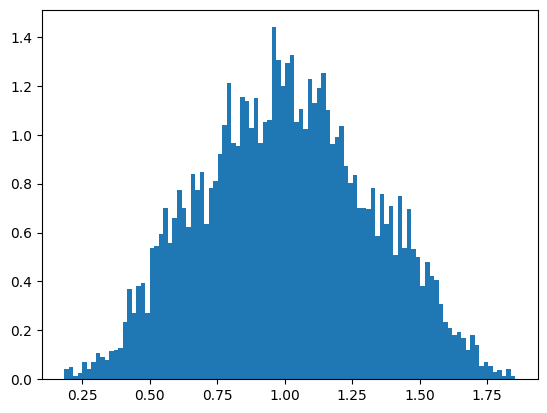

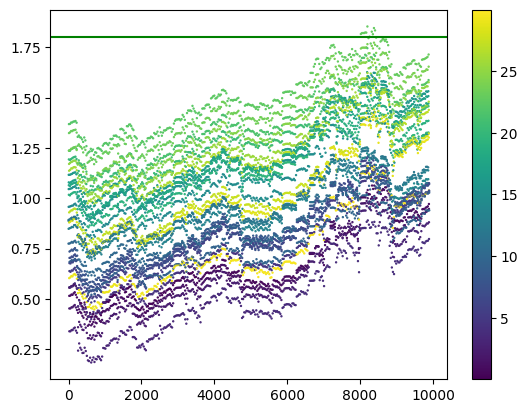

In [13]:
visualise(Axisbank2)

In [18]:
strat(Bajaj,1e-9,25,1100,0.1,30)

def Function(data,r,c):
    if(r%10==0 and c%100==0):
        print(r,c)
    if (r+1)*5<(c+1)*5:
        return Strat(data,0.01,(r+1)*5,(c+1)*5,0.1,30)
    else:
        return 0

Market returns at: 0.1157512762162618
Strategy return at : 0.42476062704268647
Sharpe : 1.3404729638802426


In [19]:
# 1. Vectorize the function, making sure it explicitly excludes 'data' by name
v_function = np.vectorize(Function, excluded=["data"])


In [20]:
def heatmap(data):
    matrix = np.fromfunction(
        lambda r, c: v_function(r=r, c=c, data=data), (20,400), dtype=int
    )
    min_val = np.min(matrix)
    max_val = np.max(matrix)
    norm = plt.Normalize(vmin=min_val, vmax=max_val)

    if min_val < 0 and max_val > 0:
        from matplotlib.colors import TwoSlopeNorm

        norm = TwoSlopeNorm(vcenter=0.0, vmin=min_val, vmax=max_val)

    # 2. Plot the matrix
    plt.figure(figsize=(10, 8))
    img = plt.imshow(matrix, cmap="RdYlGn", norm=norm, aspect="auto")

    # 3. Add the colorbar legend and labels
    cbar = plt.colorbar(img)
    cbar.set_label("Sharpe Ratio", rotation=270, labelpad=15)

    plt.xlabel("Column Parameter (c)")
    plt.ylabel("Row Parameter (r)")
    plt.title("Strategy Optimization Matrix (Red = Negative, Green = Positive)")

    plt.show()
    return matrix


In [21]:
def get_permutation(
    ohlc: pd.DataFrame, start_index: int = 0, seed=None
):
    assert start_index >= 0

    np.random.seed(seed)
    n_markets = 1
    time_index = ohlc.index
    ohlc = [ohlc]

    n_bars = len(ohlc[0])

    perm_index = start_index + 1
    perm_n = n_bars - perm_index

    start_bar = np.empty((n_markets, 4))
    relative_open = np.empty((n_markets, perm_n))
    relative_high = np.empty((n_markets, perm_n))
    relative_low = np.empty((n_markets, perm_n))
    relative_close = np.empty((n_markets, perm_n))

    for mkt_i, reg_bars in enumerate(ohlc):
        log_bars = np.log(reg_bars[['open', 'high', 'low', 'close']])

        # Get start bar
        start_bar[mkt_i] = log_bars.iloc[start_index].to_numpy()

        # Open relative to last close
        r_o = (log_bars['open'] - log_bars['close'].shift()).to_numpy()
        
        # Get prices relative to this bars open
        r_h = (log_bars['high'] - log_bars['open']).to_numpy()
        r_l = (log_bars['low'] - log_bars['open']).to_numpy()
        r_c = (log_bars['close'] - log_bars['open']).to_numpy()

        relative_open[mkt_i] = r_o[perm_index:]
        relative_high[mkt_i] = r_h[perm_index:]
        relative_low[mkt_i] = r_l[perm_index:]
        relative_close[mkt_i] = r_c[perm_index:]

    idx = np.arange(perm_n)

    # Shuffle intrabar relative values (high/low/close)
    perm1 = np.random.permutation(idx)
    relative_high = relative_high[:, perm1]
    relative_low = relative_low[:, perm1]
    relative_close = relative_close[:, perm1]

    # Shuffle last close to open (gaps) seprately
    perm2 = np.random.permutation(idx)
    relative_open = relative_open[:, perm2]

    # Create permutation from relative prices
    perm_ohlc = []
    for mkt_i, reg_bars in enumerate(ohlc):
        perm_bars = np.zeros((n_bars, 4))

        # Copy over real data before start index 
        log_bars = np.log(reg_bars[['open', 'high', 'low', 'close']]).to_numpy().copy()
        perm_bars[:start_index] = log_bars[:start_index]
        
        # Copy start bar
        perm_bars[start_index] = start_bar[mkt_i]

        for i in range(perm_index, n_bars):
            k = i - perm_index
            perm_bars[i, 0] = perm_bars[i - 1, 3] + relative_open[mkt_i][k]
            perm_bars[i, 1] = perm_bars[i, 0] + relative_high[mkt_i][k]
            perm_bars[i, 2] = perm_bars[i, 0] + relative_low[mkt_i][k]
            perm_bars[i, 3] = perm_bars[i, 0] + relative_close[mkt_i][k]

        perm_bars = np.exp(perm_bars)
        perm_bars = pd.DataFrame(perm_bars, index=time_index, columns=['open', 'high', 'low', 'close'])

        perm_ohlc.append(perm_bars)

    if n_markets > 1:
        return perm_ohlc
    else:
        return perm_ohlc[0]

In [12]:
def Strat_Ensemble_Vectorized(data, e=0.01, Ts=80, sigmao=0.1, t=30):
    # 1. Create a clean copy and reset index to ensure perfect array alignment
    Data = data.copy().reset_index(drop=True)
    n = len(Data)
    
    # 2. Compute log returns and price differences exactly as in your code
    LogReturns = np.log(Data['close'] / Data['close'].shift(1))
    Difs = Data['close'] - Data['close'].shift(1)
    
    # 3. Calculate global volatility metric matching your setup exactly
    sigma_series = Difs.dropna().expanding().std()
    sigma = sigma_series.reindex(Data.index).values  # Align index back to Data
    rho = (sigma / sigmao) ** 2
    
    # 4. Rolling indicators shifted by 1 to strictly prevent look-ahead bias
    Difs_shifted = Difs.shift(1)
    
    # Calculate Small (Ts=80) using standard pandas rolling
    Small = Difs_shifted.rolling(window=Ts).mean().values
    
    # --- LOOP-FREE LOOKBACK SUM ENGINE ---
    # Create an array of our target Tl windows ranging from 115 to 130 inclusive
    tl_range = np.arange(115, 130)  # Length: 16 elements
    
    # Generate 1D cumulative sum to extract any arbitrary rolling window sum instantly
    Difs_raw = Difs_shifted.fillna(0).values
    cusum = np.zeros(n + 1)
    np.cumsum(Difs_raw, out=cusum[1:])
    
    # Broadcast subtraction across indices and lookback windows
    idx_end = np.arange(1, n + 1)[:, None]          # Shape: (n, 1)
    idx_start = idx_end - tl_range[None, :]         # Shape: (n, 16)
    idx_start_clipped = np.maximum(0, idx_start)
    
    # Compute the rolling sums matrix and divide by window sizes to get Long means
    rolling_sums_matrix = cusum[idx_end] - cusum[idx_start_clipped]
    Long_matrix = rolling_sums_matrix / tl_range[None, :]  # Shape: (n, 16)
    
    # Pad incomplete early windows with NaN to match pandas behavior perfectly
    Long_matrix[idx_start < 0] = np.nan
    # -------------------------------------

    # 5. Execute your mathematical equations simultaneously across 2D matrix blocks
    # Broadcast 1D variables (n,) into 2D spaces (n, 16)
    a_mat = (Small / (1 + rho / Ts))[:, None]
    b_mat = Long_matrix / (1 + rho[:, None] / tl_range[None, :])
    
    denominator = ((a_mat - b_mat) ** 2) + 1e-9
    
    # Compute T matrix
    sigma_sq = (sigma * sigma)[:, None]
    T_mat = (-1 * np.log(e) * 2 * sigma_sq) / denominator
    #print(T_mat[~np.isnan(T_mat)])
    # Branching paths for 'ind' matrix depending on whether T > t
    ind_true = t * a_mat
    ind_false = T_mat * a_mat + (t - T_mat) * (e * a_mat + (1 - e) * b_mat)
    ind_matrix = np.where(T_mat > t, ind_true, ind_false)
    
    # Generate individual target signals directions matrix
    calculated_move_matrix = 1 / (1 + np.exp(-ind_matrix))
    
    # 6. Apply Softmax blending across the window axis (axis 1)
    # Numerically stable softmax using log-sum-exp trick to handle edge cases
    max_ind = np.nanmax(ind_matrix, axis=1, keepdims=True)
    exp_ind = np.exp(ind_matrix - max_ind)
    exp_ind = np.nan_to_num(exp_ind, nan=0.0)
    softmax_weights = exp_ind / (np.sum(exp_ind, axis=1, keepdims=True) + 1e-15)
    
    # Take the weighted sum of moves across the 16 different lookback options
    blended_move = np.sum(softmax_weights * calculated_move_matrix, axis=1)  # Shape: (n,)
    
    # 7. Periodic Execution Masking using the maximum window cutoff (130)
    max_Tl = 130
    indices = np.arange(n)
    trade_mask = ((indices - max_Tl - 1) % t == 0) & (indices > max_Tl + 1)
    
    # Apply trade masking and execute holding forward-fill logic
    moves = np.where(trade_mask, blended_move, np.nan)
    Moves_Series = pd.Series(moves, index=Data.index)
    Moves_Series = Moves_Series.ffill().fillna(0)
    
    # 8. Compute backtest performance metrics
    loggain = Moves_Series.shift(1) * LogReturns
    loggain.dropna(inplace=True)
    
    if len(loggain) == 0 or np.std(loggain) == 0:
        return 0.0
        
    sharperatio = np.sqrt(94500) * (np.mean(loggain) / np.std(loggain))
    marketreturn=np.exp(LogReturns.sum())-1
    stratreturn=np.exp(sum(loggain))-1
    print("Market returns at: "+str(marketreturn))
    print("Strategy return at : "+str(stratreturn))
    print("Sharpe : "+str(sharperatio))
    return sharperatio

In [15]:
Britannia=pd.read_csv("data/BRITANNIA_minute.csv")
print(Strat(Britannia,0.01,80,120,0.1,30))
print(Strat_Ensemble_Vectorized(Britannia))

0.6137823510516897
Market returns at: 0.19738357171592735
Strategy return at : 0.08318623546924053
Sharpe : 0.5265641252352798
0.5265641252352798


/tmp/ipykernel_5331/3797742431.py:64: RuntimeWarning: All-NaN slice encountered
  max_ind = np.nanmax(ind_matrix, axis=1, keepdims=True)


In [45]:
np.random.seed(42)
mock_close = 100 + np.cumsum(np.random.normal(0, 1, 500))
mock_data = pd.DataFrame({'close': mock_close})

# --- APPROACH A: YOUR ORIGINAL PANDAS MATHEMATICS (RUN IN A LOOP) ---
def run_original_loop(data, e=0.01, Ts=80, sigmao=0.1):
    Data = data.copy().reset_index(drop=True)
    n = len(Data)
    Difs = Data['close'] - Data['close'].shift(1)
    sigma = Difs.dropna().expanding().std().reindex(Data.index).values
    rho = (sigma / sigmao) ** 2
    Small = Difs.rolling(window=Ts).mean().shift(1).values
    
    tl_range = np.arange(115, 131)
    original_moves = []
    original_inds = []
    
    # Run your exact indicator math for each Tl individually
    for Tl in tl_range:
        Long = Difs.rolling(window=Tl).mean().shift(1).values
        
        a = Small / (1 + rho / Ts)
        b = Long / (1 + rho / Tl)
        denominator = ((a - b) ** 2) + 1e-9
        T = (-1 * np.log(e) * 2 * sigma * sigma) / denominator
        
        ind_true = 30 * a
        ind_false = T * a + (30 - T) * (e * a + (1 - e) * b)
        ind = np.where(T > 30, ind_true, ind_false)
        calculated_move = 1 / (1 + np.exp(-ind))
        
        original_inds.append(ind)
        original_moves.append(calculated_move)
        
    return np.array(original_inds).T, np.array(original_moves).T

# --- APPROACH B: THE NEW VECTORIZED 2D ENGINE ---
def run_vectorized_matrix(data, e=0.01, Ts=80, sigmao=0.1):
    Data = data.copy().reset_index(drop=True)
    n = len(Data)
    Difs = Data['close'] - Data['close'].shift(1)
    sigma = Difs.dropna().expanding().std().reindex(Data.index).values
    rho = (sigma / sigmao) ** 2
    Difs_shifted = Difs.shift(1)
    Small = Difs_shifted.rolling(window=Ts).mean().values
    
    tl_range = np.arange(115, 131)
    Difs_raw = Difs_shifted.fillna(0).values
    cusum = np.zeros(n + 1)
    np.cumsum(Difs_raw, out=cusum[1:])
    
    idx_end = np.arange(1, n + 1)[:, None]
    idx_start = idx_end - tl_range[None, :]
    rolling_sums_matrix = cusum[idx_end] - cusum[np.maximum(0, idx_start)]
    Long_matrix = rolling_sums_matrix / tl_range[None, :]
    Long_matrix[idx_start < 0] = np.nan
    
    a_mat = (Small / (1 + rho / Ts))[:, None]
    b_mat = Long_matrix / (1 + rho[:, None] / tl_range[None, :])
    denominator = ((a_mat - b_mat) ** 2) + 1e-9
    T_mat = (-1 * np.log(e) * 2 * (sigma * sigma)[:, None]) / denominator
    
    ind_true = 30 * a_mat
    ind_false = T_mat * a_mat + (30 - T_mat) * (e * a_mat + (1 - e) * b_mat)
    ind_matrix = np.where(T_mat > 30, ind_true, ind_false)
    calculated_move_matrix = 1 / (1 + np.exp(-ind_matrix))
    
    return ind_matrix, calculated_move_matrix

# --- RUN TESTS ---
inds_loop, moves_loop = run_original_loop(mock_data)
inds_vec, moves_vec = run_vectorized_matrix(mock_data)

# Assertions (Will raise an AssertionError if even one value differs)
# We test from index 131 onwards because that is when all windows are out of warmup
np.testing.assert_array_almost_equal(inds_loop[131:], inds_vec[131:], decimal=10)
np.testing.assert_array_almost_equal(moves_loop[131:], moves_vec[131:], decimal=10)

print("✓ VERIFICATION SUCCESSFUL: Both methods yield identical indicator and move matrices!")

✓ VERIFICATION SUCCESSFUL: Both methods yield identical indicator and move matrices!
